In [1]:
from cuda_cqed.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

In [15]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('wa', 1*2*np.pi, is_excitation=True)
sim.add_param('sqrtka', np.sqrt(0.1*2*np.pi))
sim.add_param('IC', 1)

sim.add_EOM('a', '-1j*wa*a - sqrtka**2/2*a',IC_str='IC')
sim.set_solve_type('all')

sim.specify_time(t_f=10, pts=2001)

sim.validate(print_result=False)

Recent change to specify_time(), check implementation
Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


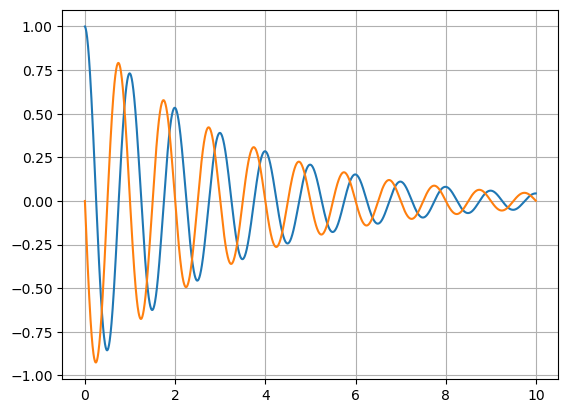

In [16]:
x, t = sim.quick_trace()


plt.plot(t, x[0,:])
plt.plot(t, x[1,:])
plt.grid()
plt.show()

In [4]:
x = [4,5,6,76,87]
x[-1:]

[87]

In [5]:
b = x[0,:]+1j*x[1,:]
bb = x[2,:]+1j*x[3,:]
nb = x[4,:]+1j*x[5,:]

In [6]:
def plot_Qfunc(a, aa, na, ax=None, plot_arg=None):

    if ax == None:
        ax = plt.gca()
    
    ad = np.conjugate(a)
    adad = np.conjugate(aa)
    sxx = 1/2 + 1/2*( (aa - a*a) + 2*(na - ad*a) + (adad - ad*ad))
    syy = 1/2 - 1/2*( (aa - a*a) - 2*(na - ad*a) + (adad - ad*ad))
    sxy = np.imag(1/2*((aa - a*a) - (adad - ad*ad)))
    covar =  np.real(np.array([[sxx, sxy], [sxy, syy]]))

    print(covar)
    print(' ')

    phi = np.linspace(0, 2*np.pi, 101)
    
    print(np.argsort(np.linalg.eig(covar)[0]))

    order = np.argsort(np.linalg.eig(covar)[0])
    major_idx = order[1]
    minor_idx = order[0]
    
    theta = -np.angle(np.linalg.eig(covar)[1][:,1][minor_idx]+1j*np.linalg.eig(covar)[1][:,1][major_idx])
    Smajor = np.sort(np.linalg.eig(covar)[0])[major_idx]
    Sminor = np.sort(np.linalg.eig(covar)[0])[minor_idx]
    
    x1 = np.sqrt(Smajor)*np.cos(phi)*2
    y1 = np.sqrt(Sminor)*np.sin(phi)*2
    
    x2 = x1*np.cos(theta) + y1*np.sin(theta) + np.real(a)
    y2 = -x1*np.sin(theta) + y1*np.cos(theta) + np.imag(a)

    if plot_arg == None:
        ax.plot(x2,y2)
    else:
        ax.plot(x2,y2,plot_arg)
    # ax.xlim([-7,7])
    # ax.ylim([-7,7])
    # plt.gca().set_aspect('equal')
    # plt.grid()
    # plt.show()


In [7]:
# i = 0
# j = -1
# plot_Qfunc(b[i,j], bb[i,j], nb[i,j])
# plt.xlim([-7,7])
# plt.ylim([-7,7])
# plt.gca().set_aspect('equal')
# plt.grid()
# plt.show()

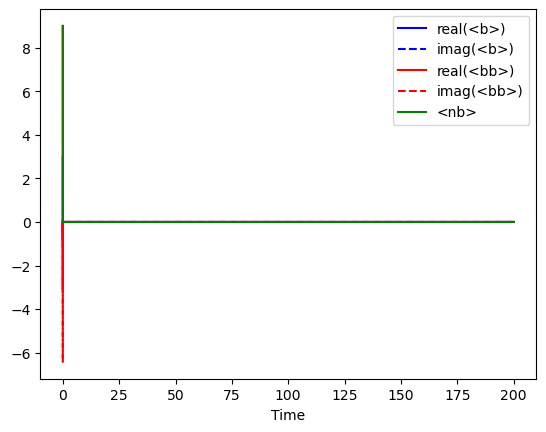

In [8]:
tlist = np.unique(t)
plt.plot(tlist, np.real(b),'b-',label='real(<b>)')
plt.plot(tlist, np.imag(b),'b--',label='imag(<b>)')
plt.plot(tlist, np.real(bb),'r-',label='real(<bb>)')
plt.plot(tlist, np.imag(bb),'r--',label='imag(<bb>)')
plt.plot(tlist, np.real(nb),'g',label='<nb>')
plt.legend()
plt.xlabel('Time')
plt.show()